In [2]:
!pip install numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 56.1 MB/s  0:00:006m0:00:01


In [4]:
!pip install pandas numpy openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 50.2 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [openpyxl]3/4 [openpyxl]


In [6]:
import os, glob

# 1) In thư mục hiện tại + /mnt/data (hay gặp trên môi trường notebook/server)
print("CWD:", os.getcwd())
print("CWD files:", os.listdir())

if os.path.exists("/mnt/data"):
    print("/mnt/data files:", os.listdir("/mnt/data"))
else:
    print("No /mnt/data directory")

# 2) Dò tất cả file excel có thể có
candidates = []
for base in [os.getcwd(), "/mnt/data", "."]:
    if base and os.path.exists(base):
        candidates += glob.glob(os.path.join(base, "*.xlsx"))
        candidates += glob.glob(os.path.join(base, "*.xls"))

# Dò sâu hơn (trường hợp file nằm thư mục con)
for base in [os.getcwd(), "/mnt/data", "."]:
    if base and os.path.exists(base):
        candidates += glob.glob(os.path.join(base, "**/*.xlsx"), recursive=True)
        candidates += glob.glob(os.path.join(base, "**/*.xls"), recursive=True)

# Loại trùng, in ra
candidates = sorted(set(candidates))
print("\nExcel candidates:")
for p in candidates:
    print(" -", p)

CWD: /workspaces/sr_hca
CWD files: ['.git', 'DataAnalys.xlsx', '.ipynb_checkpoints', 'README.md', 'NCKH.ipynb']
No /mnt/data directory

Excel candidates:
 - ./DataAnalys.xlsx
 - /workspaces/sr_hca/DataAnalys.xlsx


In [8]:
import re
import pandas as pd

INPUT_PATH = "./DataAnalys.xlsx"
OUTPUT_PATH = "./DataAnalys_clean.xlsx"

# Đọc sheet đầu tiên
xls = pd.ExcelFile(INPUT_PATH)
df = pd.read_excel(INPUT_PATH, sheet_name=xls.sheet_names[0])

# Regex bỏ tiền tố số thứ tự: "1. " hoặc "2) "
PREFIX_RE = re.compile(r"^\s*\d+\s*[\.\)]\s*")

def clean_cell(x):
    """
    - Giữ nguyên NaN
    - Chuẩn hoá mỗi 'mảnh' ngăn bởi dấu phẩy:
        + bỏ prefix 1. / 2) ở đầu mảnh
        + strip khoảng trắng
    - GIỮ nguyên dấu phẩy (không biến thành list)
    - GIỮ nguyên dấu '/' (không tách, không xử lý)
    """
    if pd.isna(x):
        return x

    s = str(x).strip()
    if s == "":
        return s

    # Nếu có dấu phẩy, coi như nhiều lựa chọn: làm sạch từng phần rồi join lại bằng ", "
    if "," in s:
        parts = [p.strip() for p in s.split(",")]
        parts = [PREFIX_RE.sub("", p).strip() for p in parts]
        parts = [p for p in parts if p != ""]
        return ", ".join(parts)

    # Không có dấu phẩy: chỉ bỏ prefix nếu có
    return PREFIX_RE.sub("", s).strip()

# Áp dụng cho toàn bộ dataframe
df_clean = df.applymap(clean_cell)

# Lưu lại 1 file sạch
with pd.ExcelWriter(OUTPUT_PATH, engine="openpyxl") as w:
    df_clean.to_excel(w, index=False, sheet_name="clean")

print("Saved:", OUTPUT_PATH)
print(df_clean.head(3))


/tmp/ipykernel_806/599057317.py:41: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_clean = df.applymap(clean_cell)


Saved: ./DataAnalys_clean.xlsx
  A1. Giới tính: A2. Ngành học: A3. Sinh viên: A4. Học lực học kỳ gần nhất:  \
0            Nam           Luật          Năm 1                     Xuất sắc   
1            Nam           Luật          Năm 1                     Xuất sắc   
2             Nữ           Luật          Năm 1                         Giỏi   

  B1. Tổng thời lượng sử dụng trong ngày:  \
0                          Từ 2 đến 4 giờ   
1                          Từ 2 đến 4 giờ   
2                           Nhỏ hơn 2 giờ   

  B2. Khoảng thời gian sử dụng trong ngày:  \
0                                      Tối   
1                        Sáng, Trưa, Chiều   
2                                Trưa, Tối   

       B3. Bạn thường sử dụng Facebook cho mục đích:  \
0   Giải trí, Học tập, công việc, Tìm kiếm thông tin   
1   Học tập, công việc, Giao tiếp, Mua sắm, bán hàng   
2  Giải trí, Học tập, công việc, Giao tiếp, Tìm k...   

  B4. Phương tiện, thiết bị sử dụng:         C1.1            

Mapping nhóm A theo tên cột thực tế:
  A1 -> A1. Giới tính:
  A2 -> A2. Ngành học:
  A3 -> A3. Sinh viên:
  A4 -> A4. Học lực học kỳ gần nhất:


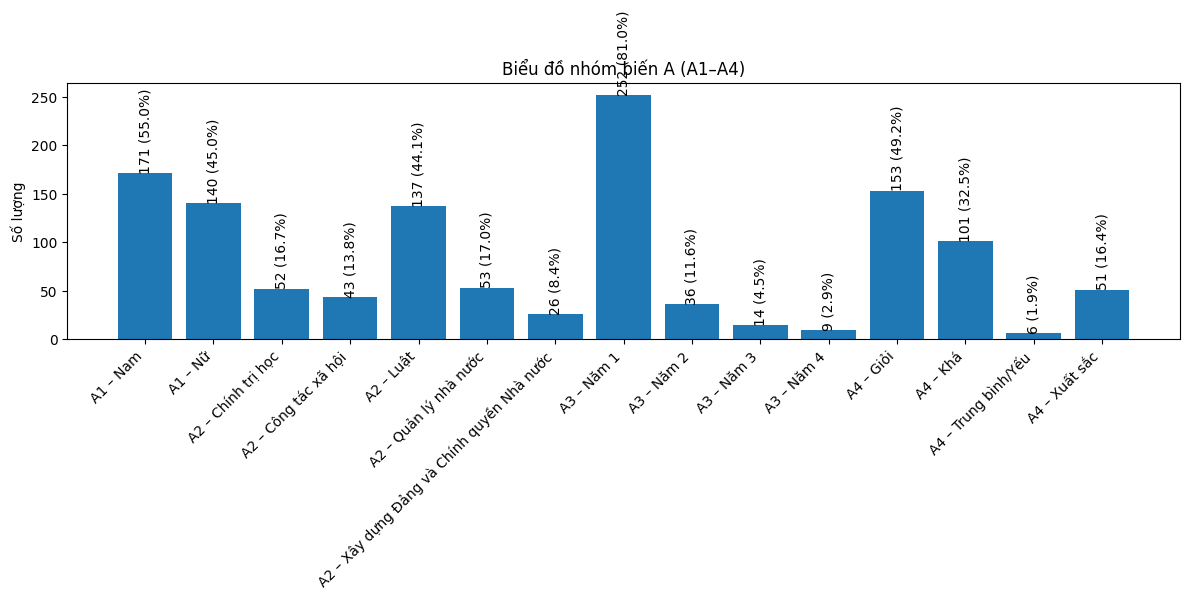

In [10]:
import re
import pandas as pd
import matplotlib.pyplot as plt

PATH = "/workspaces/sr_hca/DataAnalys.xlsx"

# ========== 1) Read
df = pd.read_excel(PATH)

# ========== 2) Clean theo rule của mày (không tách '/', chỉ xử lý prefix số và dấu phẩy)
PREFIX_RE = re.compile(r"^\s*\d+\s*[\.\)]\s*")

def clean_cell(x):
    if pd.isna(x):
        return x
    s = str(x).strip()
    if s == "":
        return s

    if "," in s:
        parts = [p.strip() for p in s.split(",")]
        parts = [PREFIX_RE.sub("", p).strip() for p in parts]
        parts = [p for p in parts if p != ""]
        return ", ".join(parts)

    return PREFIX_RE.sub("", s).strip()

for c in df.columns:
    if df[c].dtype == "object":
        df[c] = df[c].map(clean_cell)

# ========== 3) Tự bắt cột A1–A4 dựa trên TÊN CỘT THẬT
def pick_col(code: str, columns) -> str | None:
    cols = list(columns)
    code_low = code.lower().strip()

    # 1) exact match (sau strip/lower)
    for col in cols:
        if str(col).strip().lower() == code_low:
            return col

    # 2) bắt đầu bằng code (A1..., A1. ..., A1 - ...)
    pat_start = re.compile(rf"^\s*{re.escape(code)}\b", re.IGNORECASE)
    for col in cols:
        if pat_start.search(str(col)):
            return col

    # 3) chứa token code (vd: "Câu A1 ...")
    pat_token = re.compile(rf"\b{re.escape(code)}\b", re.IGNORECASE)
    for col in cols:
        if pat_token.search(str(col)):
            return col

    return None

wanted = ["A1", "A2", "A3", "A4"]
col_map = {w: pick_col(w, df.columns) for w in wanted}

print("Mapping nhóm A theo tên cột thực tế:")
for k, v in col_map.items():
    print(f"  {k} -> {v}")

missing = [k for k, v in col_map.items() if v is None]
if missing:
    # Nếu fail, in danh sách cột để mày nhìn/tao debug tiếp ngay
    print("\nKhông bắt được các mã:", missing)
    print("Danh sách cột trong file:")
    print(list(df.columns))
    raise KeyError(f"Không tìm thấy cột tương ứng cho: {missing}")

A_cols_real = [col_map[w] for w in wanted]

# ========== 4) Count + % (tách chọn nhiều theo dấu phẩy, KHÔNG tách '/')
rows = []
for code, col in zip(wanted, A_cols_real):
    for v in df[col].dropna():
        for opt in str(v).split(","):
            ans = opt.strip()
            if ans:
                rows.append({"question": code, "answer": ans})

df_long = pd.DataFrame(rows)

count_df = (
    df_long.groupby(["question", "answer"])
    .size()
    .reset_index(name="count")
)
count_df["total"] = count_df.groupby("question")["count"].transform("sum")
count_df["percent"] = count_df["count"] / count_df["total"] * 100

# ========== 5) Vẽ 1 biểu đồ duy nhất + chú thích count + %
plt.figure(figsize=(12, 6))

labels = [f"{r.question} – {r.answer}" for r in count_df.itertuples(index=False)]
values = count_df["count"].tolist()

plt.bar(labels, values)

for i, r in enumerate(count_df.itertuples(index=False)):
    plt.text(
        i, r.count,
        f"{r.count} ({r.percent:.1f}%)",
        ha="center", va="bottom",
        rotation=90
    )

plt.title("Biểu đồ nhóm biến A (A1–A4)")
plt.ylabel("Số lượng")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


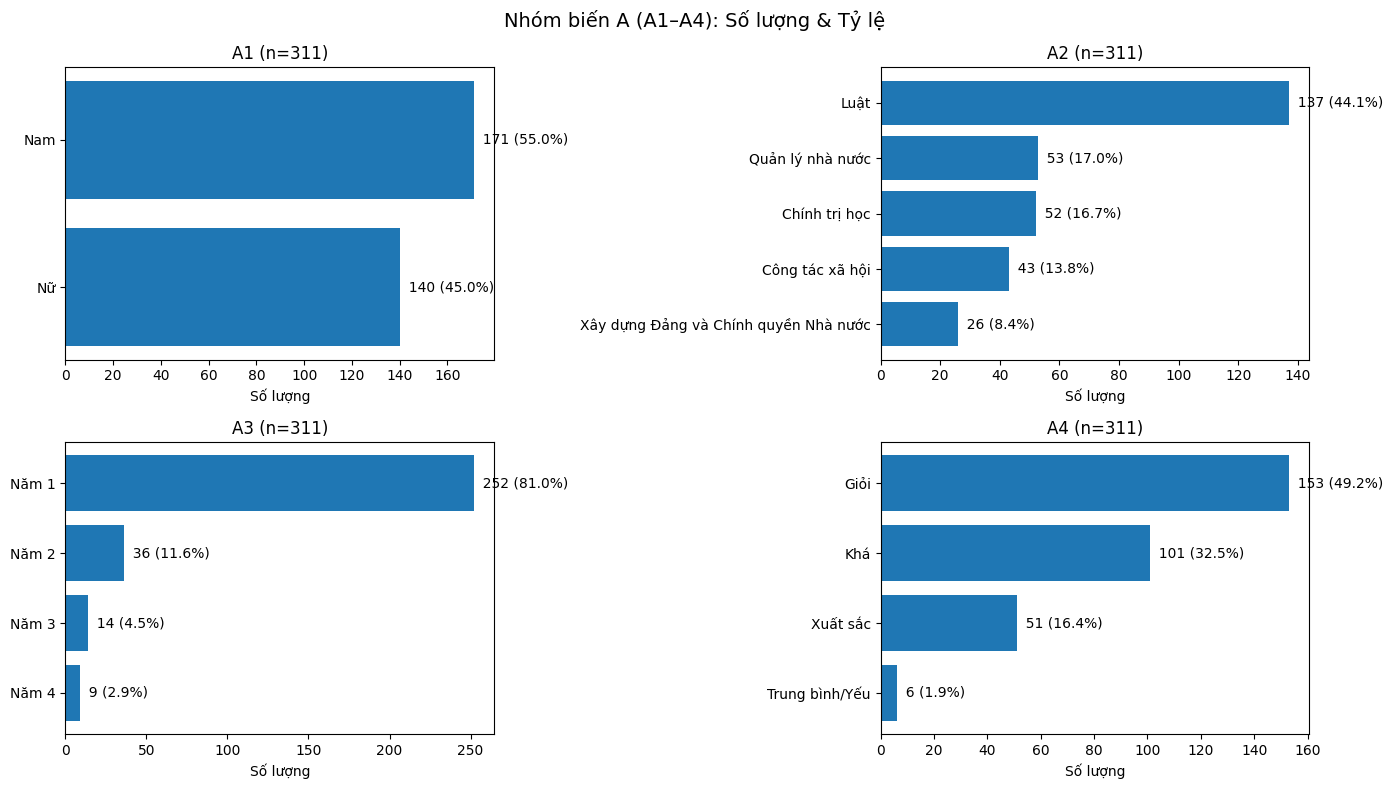

In [11]:
import re
import pandas as pd
import matplotlib.pyplot as plt

PATH = "/workspaces/sr_hca/DataAnalys.xlsx"

# ===== 1) Read + clean theo rule của bạn
df = pd.read_excel(PATH)

PREFIX_RE = re.compile(r"^\s*\d+\s*[\.\)]\s*")

def clean_cell(x):
    if pd.isna(x):
        return x
    s = str(x).strip()
    if s == "":
        return s
    if "," in s:
        parts = [p.strip() for p in s.split(",")]
        parts = [PREFIX_RE.sub("", p).strip() for p in parts]
        parts = [p for p in parts if p != ""]
        return ", ".join(parts)  # giữ chuỗi, không tách '/'
    return PREFIX_RE.sub("", s).strip()

for c in df.columns:
    if df[c].dtype == "object":
        df[c] = df[c].map(clean_cell)

# ===== 2) Tự bắt cột A1–A4 theo tên cột thực tế
def pick_col(code: str, columns):
    code_low = code.lower().strip()

    for col in columns:
        if str(col).strip().lower() == code_low:
            return col

    pat_start = re.compile(rf"^\s*{re.escape(code)}\b", re.IGNORECASE)
    for col in columns:
        if pat_start.search(str(col)):
            return col

    pat_token = re.compile(rf"\b{re.escape(code)}\b", re.IGNORECASE)
    for col in columns:
        if pat_token.search(str(col)):
            return col

    return None

wanted = ["A1", "A2", "A3", "A4"]
col_map = {w: pick_col(w, df.columns) for w in wanted}

missing = [k for k, v in col_map.items() if v is None]
if missing:
    print("Không tìm thấy:", missing)
    print("Cột hiện có:", list(df.columns))
    raise KeyError("Thiếu cột nhóm A")

# ===== 3) Hàm tính count + % theo số người trả lời (đúng cho cả chọn 1 & chọn nhiều)
def summarize_question(series: pd.Series):
    s = series.dropna().astype(str)
    n = len(s)  # số người trả lời câu này

    counts = {}
    for i, val in s.items():
        # chọn nhiều: tách theo dấu phẩy; chọn 1: split vẫn ra 1 phần
        opts = [o.strip() for o in val.split(",") if o.strip() != ""]
        # mỗi respondent chỉ tính 1 lần cho mỗi option
        for opt in set(opts):
            counts[opt] = counts.get(opt, 0) + 1

    out = (
        pd.DataFrame({"answer": list(counts.keys()), "count": list(counts.values())})
        .sort_values("count", ascending=True)  # để barh đẹp (tăng dần)
    )
    out["percent"] = out["count"] / n * 100 if n > 0 else 0
    return out, n

# ===== 4) Vẽ 1 figure 2×2 (logic, dễ đọc)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, code in zip(axes, wanted):
    col = col_map[code]
    summary, n = summarize_question(df[col])

    ax.barh(summary["answer"], summary["count"])
    ax.set_title(f"{code} (n={n})")
    ax.set_xlabel("Số lượng")

    # annotation count + %
    for y, (cnt, pct) in enumerate(zip(summary["count"], summary["percent"])):
        ax.text(cnt, y, f"  {cnt} ({pct:.1f}%)", va="center")

plt.suptitle("Nhóm biến A (A1–A4): Số lượng & Tỷ lệ", fontsize=14)
plt.tight_layout()
plt.show()


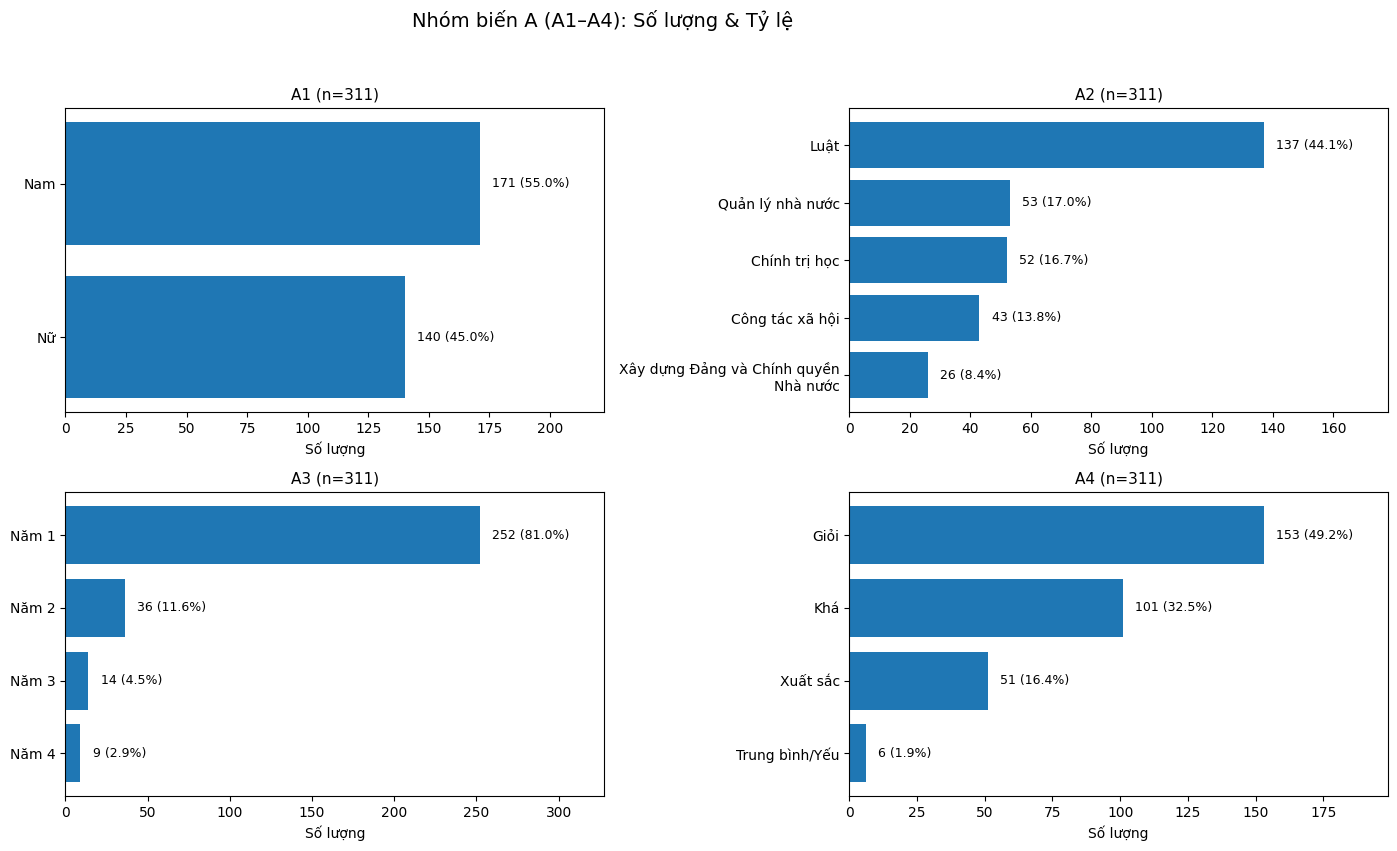

Đã xuất: bieudo_nhom_A_A1_A4.png


In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from textwrap import wrap

PATH = "DataAnalys.xlsx"
OUT_PNG = "bieudo_nhom_A_A1_A4.png"

# ===== 1) Read + clean (đúng rule đã chốt)
df = pd.read_excel(PATH)

PREFIX_RE = re.compile(r"^\s*\d+\s*[\.\)]\s*")

def clean_cell(x):
    if pd.isna(x):
        return x
    s = str(x).strip()
    if s == "":
        return s
    if "," in s:
        parts = [p.strip() for p in s.split(",")]
        parts = [PREFIX_RE.sub("", p).strip() for p in parts]
        parts = [p for p in parts if p != ""]
        return ", ".join(parts)
    return PREFIX_RE.sub("", s).strip()

for c in df.columns:
    if df[c].dtype == "object":
        df[c] = df[c].map(clean_cell)

# ===== 2) Bắt cột A1–A4 theo tên cột thật
def pick_col(code, columns):
    for col in columns:
        if str(col).strip().lower().startswith(code.lower()):
            return col
    return None

wanted = ["A1", "A2", "A3", "A4"]
col_map = {w: pick_col(w, df.columns) for w in wanted}

# ===== 3) Hàm thống kê (count + % theo số người)
def summarize(series):
    s = series.dropna().astype(str)
    n = len(s)
    counts = {}
    for v in s:
        opts = [o.strip() for o in v.split(",") if o.strip()]
        for o in set(opts):
            counts[o] = counts.get(o, 0) + 1

    out = (
        pd.DataFrame({"answer": list(counts.keys()), "count": list(counts.values())})
        .sort_values("count", ascending=True)
    )
    out["percent"] = out["count"] / n * 100
    return out, n

# ===== 4) VẼ FIGURE 2×2 – KHÔNG ĐÈ CHỮ
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()

def wrap_labels(labels, width=30):
    return ["\n".join(wrap(l, width)) for l in labels]

for ax, code in zip(axes, wanted):
    col = col_map[code]
    summary, n = summarize(df[col])

    labels = wrap_labels(summary["answer"].tolist())
    ax.barh(range(len(summary)), summary["count"])
    ax.set_yticks(range(len(summary)))
    ax.set_yticklabels(labels)
    ax.set_title(f"{code} (n={n})", fontsize=11)
    ax.set_xlabel("Số lượng")

    # nới trục X để chừa chỗ ghi số
    max_count = summary["count"].max()
    ax.set_xlim(0, max_count * 1.3)

    for i, (cnt, pct) in enumerate(zip(summary["count"], summary["percent"])):
        ax.text(
            cnt + max_count * 0.03,
            i,
            f"{cnt} ({pct:.1f}%)",
            va="center",
            fontsize=9
        )

fig.suptitle("Nhóm biến A (A1–A4): Số lượng & Tỷ lệ", fontsize=14)

# chừa lề TRÁI + TRÊN để không bị cắt khi save
plt.tight_layout(rect=[0.12, 0.04, 1, 0.95])

# ===== 5) SAVE PNG – CHUẨN BÁO CÁO
plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
plt.show()

print("Đã xuất:", OUT_PNG)

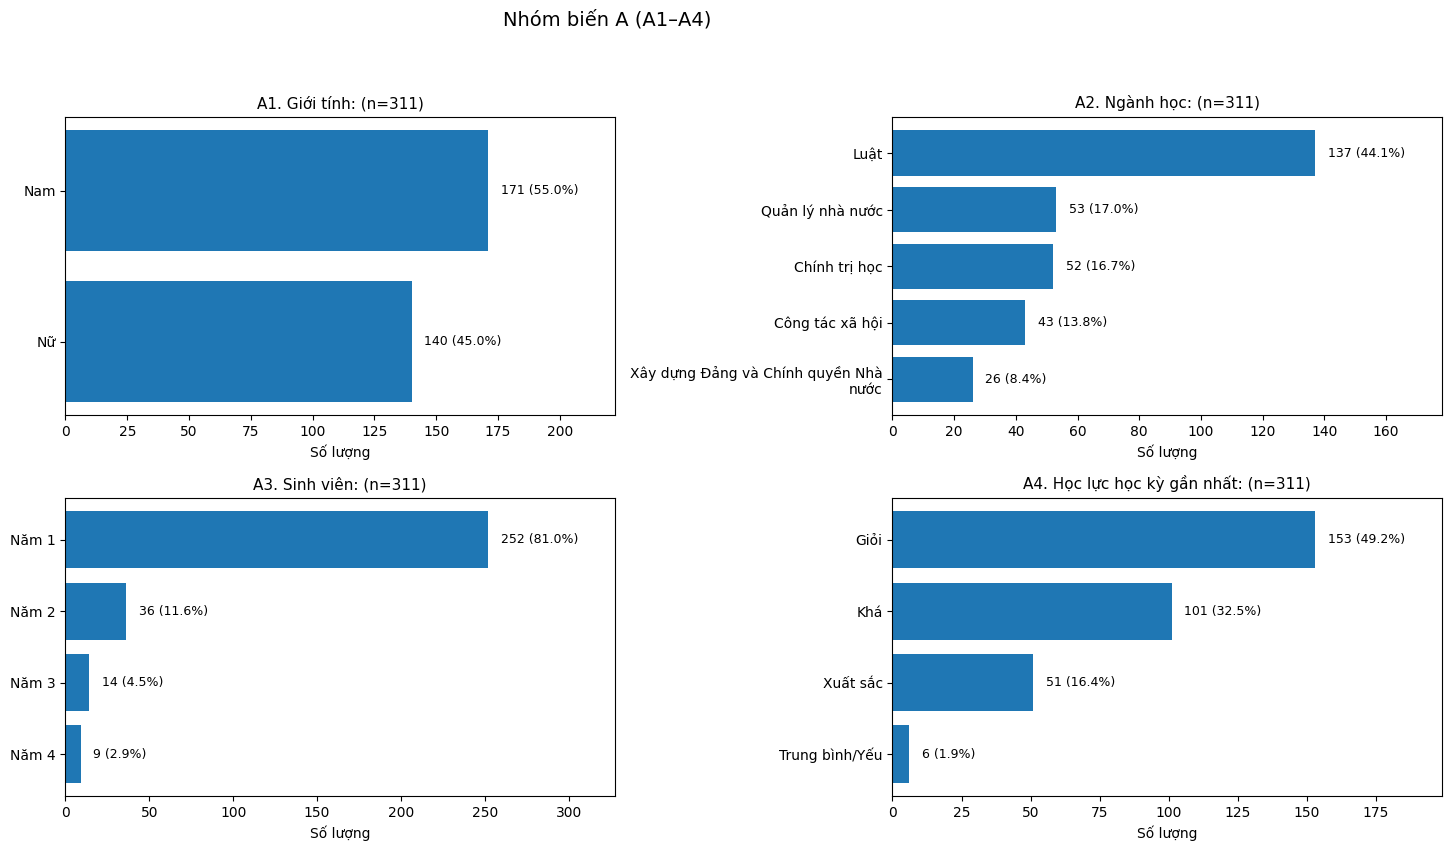

Đã xuất: bieudo_nhom_A_A1_A4.png


In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from textwrap import wrap

PATH = "DataAnalys.xlsx"        # <<< SỬA nếu cần
OUT_PNG = "bieudo_nhom_A_A1_A4.png"

# ===== 1) Read + clean theo rule đã chốt
df = pd.read_excel(PATH)

PREFIX_RE = re.compile(r"^\s*\d+\s*[\.\)]\s*")

def clean_cell(x):
    if pd.isna(x):
        return x
    s = str(x).strip()
    if s == "":
        return s
    if "," in s:
        parts = [p.strip() for p in s.split(",")]
        parts = [PREFIX_RE.sub("", p).strip() for p in parts]
        parts = [p for p in parts if p != ""]
        return ", ".join(parts)
    return PREFIX_RE.sub("", s).strip()

for c in df.columns:
    if df[c].dtype == "object":
        df[c] = df[c].map(clean_cell)

# ===== 2) Tự bắt cột A1–A4 + GIỮ NGUYÊN TÊN CÂU HỎI
def pick_col(code, columns):
    for col in columns:
        if str(col).strip().lower().startswith(code.lower()):
            return col
    return None

wanted = ["A1", "A2", "A3", "A4"]
col_map = {w: pick_col(w, df.columns) for w in wanted}

# ===== 3) Thống kê count + % theo số người
def summarize(series):
    s = series.dropna().astype(str)
    n = len(s)
    counts = {}
    for v in s:
        opts = [o.strip() for o in v.split(",") if o.strip()]
        for o in set(opts):
            counts[o] = counts.get(o, 0) + 1

    out = (
        pd.DataFrame({"answer": list(counts.keys()), "count": list(counts.values())})
        .sort_values("count", ascending=True)
    )
    out["percent"] = out["count"] / n * 100 if n > 0 else 0
    return out, n

# ===== 4) VẼ FIGURE 2×2 – CÓ TÊN CÂU HỎI ĐẦY ĐỦ
fig, axes = plt.subplots(2, 2, figsize=(17, 9))
axes = axes.flatten()

def wrap_labels(labels, width=32):
    return ["\n".join(wrap(l, width)) for l in labels]

for ax, code in zip(axes, wanted):
    col = col_map[code]              # tên cột THẬT (vd: "A1. Giới tính")
    summary, n = summarize(df[col])

    labels = wrap_labels(summary["answer"].tolist())
    ax.barh(range(len(summary)), summary["count"])
    ax.set_yticks(range(len(summary)))
    ax.set_yticklabels(labels)

    # 🔥 TÊN CÂU HỎI ĐẦY ĐỦ
    ax.set_title(f"{col} (n={n})", fontsize=11)
    ax.set_xlabel("Số lượng")

    max_count = summary["count"].max()
    ax.set_xlim(0, max_count * 1.3)

    for i, (cnt, pct) in enumerate(zip(summary["count"], summary["percent"])):
        ax.text(
            cnt + max_count * 0.03,
            i,
            f"{cnt} ({pct:.1f}%)",
            va="center",
            fontsize=9
        )

fig.suptitle("Nhóm biến A (A1–A4)", fontsize=14)

plt.tight_layout(rect=[0.14, 0.04, 1, 0.94])

# ===== 5) XUẤT PNG
plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
plt.show()

print("Đã xuất:", OUT_PNG)